In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib as mpl

from scipy.sparse.linalg import expm_multiply, expm
from scipy.sparse import diags
from utils import *
from ionq_circuit_utils import *

from os import getenv
from os.path import join
import json
import hashlib
import time

import networkx as nx
from random import shuffle, seed

import requests

from braket.circuits import Circuit
from braket.devices import LocalSimulator
from braket.aws import AwsDevice, AwsQuantumTask

# from simuq import QSystem
# from simuq import Qubit
# from simuq.ionq import IonQProvider, IonQAPICircuit

from qiskit import QuantumCircuit, transpile

from dotenv import load_dotenv
load_dotenv()

True

In [2]:
IONQ_API_KEY = getenv('IONQ_API_KEY')

# Helper functions

In [3]:
# Sends job and returns job_id
def send_job(job):
    headers = {
        "Authorization": f"apiKey {IONQ_API_KEY}",
        "Content-Type": "application/json"
    }
    req = requests.post("https://api.ionq.co/v0.3/jobs", json=job, headers=headers)
    try:
        job_id = json.loads(req.content)['id']
    except KeyError:
        print(req)
        raise KeyError(f"Error sending job. Error message: {req.content['''message''']}")
    return job_id

In [4]:
def get_ionq_single_job_result(job_id, codewords, use_error_mitigation=False):
    # Get job
    print("Getting job:", job_id)

    headers = {
        "Authorization": f"apiKey {IONQ_API_KEY}"
    }

    req = requests.get(f"https://api.ionq.co/v0.3/jobs/{job_id}", headers=headers)
    

    status = json.loads(req.content)['status']
    print(f"Job status: {status}")
    if status == "completed":
        
        headers = {
            "Authorization": f"apiKey {IONQ_API_KEY}"
        }
        if use_error_mitigation:
            params = {"sharpen": "true"} # plural voting aggregation
        else:
            params = {"sharpen": "false"}
        req = requests.get(f"https://api.ionq.co/v0.3/jobs/{job_id}/results", headers=headers, params=params)
        results = json.loads(req.content)
        if "error" in results.keys():
            raise AttributeError(results["message"])
        else:
            freq = np.zeros(len(codewords))
            for i in range(len(codewords)):
                if str(codewords[i]) in results.keys():
                    freq[i] = results[str(codewords[i])]
            return freq
    else:
        raise FileNotFoundError("Job not completed")
    
def get_results(job_ids_path, num_time_points, codewords, use_error_mitigation=False):
    with open(job_ids_path, "r") as f:
        job_ids = json.load(f)
        f.close()

    freq = np.zeros((num_time_points, len(codewords)))
    for i, job_id in enumerate(job_ids):

        freq[i] = get_ionq_single_job_result(job_id, codewords, use_error_mitigation)

    return freq

def cancel_job(job_id):
    print("Cancelling job:", job_id)

    headers = {
        "Authorization": f"apiKey {IONQ_API_KEY}"
    }
    r = requests.put(f"https://api.ionq.co/v0.3/jobs/{job_id}/status/cancel", headers=headers)
    return r

1D advection equation implementation

In [5]:
def get_adv_circuit(N, t, c, R, r, encoding="one-hot", dimension=1):

    instructions = []
    dx = R / (N - 1)

    # Use randomized first order Trotter
    dt = t / r
    
    np.random.seed(int(t * r))
    for _ in range(r):
        for i in range(dimension):
            if encoding == "one-hot":
                '''Second order Trotter'''
                for j in np.arange(0, N, 2):
                    instructions.append(get_rxy(0.5 * (c / (2 * dx)) * dt, targets=[int(i * N + j),int(i * N + ((j + 1) % N))]))
                    instructions.append(get_rxy(-0.5 * (c / (2 * dx)) * dt, targets=[int(i * N + ((j + 1) % N)),int(i * N + j)]))
                for j in np.arange(1, N, 2):
                    instructions.append(get_rxy((c / (2 * dx)) * dt, targets=[int(i * N + j),int(i * N + ((j + 1) % N))]))
                    instructions.append(get_rxy(-(c / (2 * dx)) * dt, targets=[int(i * N + ((j + 1) % N)),int(i * N + j)]))
                for j in np.arange(0, N, 2):
                    instructions.append(get_rxy(-0.5 *(c / (2 * dx)) * dt, targets=[int(i * N + ((j + 1) % N)),int(i * N + j)]))
                    instructions.append(get_rxy(0.5 * (c / (2 * dx)) * dt, targets=[int(i * N + j),int(i * N + ((j + 1) % N))]))

                '''Randomized first-order Trotter'''
                # if np.random.rand() < 0.5:
                #     for j in np.arange(0, N-1, 2):
                #         instructions.append(get_rxy((c / (2 * dx)) * dt, targets=[int(i * N + j),int(i * N + j + 1)]))
                #         instructions.append(get_rxy(-(c / (2 * dx)) * dt, targets=[int(i * N + j + 1),int(i * N + j)]))
                #     for j in np.arange(1, N-1, 2):
                #         instructions.append(get_rxy((c / (2 * dx)) * dt, targets=[int(i * N + j),int(i * N + j + 1)]))
                #         instructions.append(get_rxy(-(c / (2 * dx)) * dt, targets=[int(i * N + j + 1),int(i * N + j)]))
                # else:
                #     for j in np.arange(1, N-1, 2):
                #         instructions.append(get_rxy((c / (2 * dx)) * dt, targets=[int(i * N + j),int(i * N + j + 1)]))
                #         instructions.append(get_rxy(-(c / (2 * dx)) *dt, targets=[int(i * N + j + 1),int(i * N + j)]))
                #     for j in np.arange(0, N-1, 2):
                #         instructions.append(get_rxy(-(c / (2 * dx)) * dt, targets=[int(i * N + j + 1),int(i * N + j)]))
                #         instructions.append(get_rxy((c / (2 * dx)) * dt, targets=[int(i * N + j),int(i * N + j + 1)]))

            elif encoding == "one-cold":
                '''Second order Trotter'''
                for j in np.arange(0, N, 2):
                    instructions.append(get_rxy(-0.5 * (c / (2 * dx)) * dt, targets=[int(i * N + j),int(i * N + ((j + 1) % N))]))
                    instructions.append(get_rxy(0.5 * (c / (2 * dx)) * dt, targets=[int(i * N + ((j + 1) % N)),int(i * N + j)]))
                for j in np.arange(1, N, 2):
                    instructions.append(get_rxy(-(c / (2 * dx)) * dt, targets=[int(i * N + j),int(i * N + ((j + 1) % N))]))
                    instructions.append(get_rxy((c / (2 * dx)) * dt, targets=[int(i * N + ((j + 1) % N)),int(i * N + j)]))
                for j in np.arange(0, N, 2):
                    instructions.append(get_rxy(0.5 *(c / (2 * dx)) * dt, targets=[int(i * N + ((j + 1) % N)),int(i * N + j)]))
                    instructions.append(get_rxy(-0.5 * (c / (2 * dx)) * dt, targets=[int(i * N + j),int(i * N + ((j + 1) % N))]))

    return instructions

def run_advection_1d(N, T, c, R, r, mu, sigma, num_time_points, num_shots, device, save_dir, use_real_machine, 
           job_ids_filename, encoding, use_noisy_sim=False):
    


    task_name = "1D advection equation"
    dimension = 1
    t_vals = np.linspace(0, T, num_time_points)
    # n = num_qubits_per_dim(N, encoding)

    job_ids = []

    # state prep circ
    gaussian_dist = np.zeros(N, dtype=np.complex64)
    # Initialize to Gaussian
    for i in range(N):
        gaussian_dist[i] = np.exp(-0.5 * ((i / (N-1) - mu) / sigma) ** 2)
    gaussian_dist /= np.linalg.norm(gaussian_dist)

    for i, t in enumerate(t_vals):
        
        print(f"Unitless time: {t : 0.3f}")

        # use braket simulator and get amplitudes of state vector
        instructions = state_prep_circuit(N, dimension, gaussian_dist, encoding)
        instructions += get_adv_circuit(N, t, c, R, r, encoding=encoding)
        native_instructions, _ = get_native_circuit(N, instructions)
        one_qubit_gate_count, two_qubit_gate_count = get_native_gate_counts(native_instructions)
        print(f"1q gates: {one_qubit_gate_count}, 2q gates: {two_qubit_gate_count}")
        # if optimize_circuit:
        #     # Optimize with Qiskit
        #     compiled_circuit = transpile(get_qiskit_circuit(n * dimension, instructions), basis_gates=['rxx', 'rx', 'ry', 'rz'], optimization_level=3)
        #     instructions = get_circuit_from_qiskit(compiled_circuit)
            
        if use_real_machine:
            
            # Create the job json and save it
            job = get_ionq_job_json(task_name, N, dimension, num_shots, device, encoding, instructions, use_native_gates=True)
            
            print(f"Saving in {save_dir}")
            with open(join(save_dir, f"job_{i}.json"), "w") as f:
                json.dump(job, f, default=int)

            # Send the job and get the job id
            job_id = send_job(job)
            print("Job id:", job_id)
            job_ids.append(job_id)
        else:
            
            # native_instructions, qubit_phase = get_native_circuit(dimension * n, instructions)
            # one_qubit_gate_count, two_qubit_gate_count = get_native_gate_counts(native_instructions)
            # print(f"1q gates: {one_qubit_gate_count}, 2q gates: {two_qubit_gate_count}")
            # circuit = get_braket_native_circuit(native_instructions)
            # for j in range(n * dimension):
            #     circuit.rz(j, -qubit_phase[j] * (2 * np.pi))

            # circuit.amplitude(state=bitstrings)

            # # Run on simulator
            # task = device.run(circuit)
            # # occurrences = get_occurrences(N, task.result().measurements, num_shots, dimension, encoding, periodic=False)
            # # sim_freq[i] = occurrences.flatten() / np.sum(occurrences)

            # amplitudes_res = task.result().values[0]
            # for j in range(N ** dimension):
            #     sim_freq[i,j] = np.abs(amplitudes_res[bitstrings[j]]) ** 2


            # Create the job json and save it
            job = get_ionq_job_json(task_name, N, dimension, num_shots, device, encoding, instructions, use_native_gates=True, noisy_simulator=use_noisy_sim)
            
            print(f"Saving in {save_dir}")
            with open(join(save_dir, f"job_{i}.json"), "w") as f:
                json.dump(job, f, default=int)

            # Send the job and get the job id
            job_id = send_job(job)
            print("Job id:", job_id)
            job_ids.append(job_id)

    print(f"Saving IonQ job ids as {job_ids_filename}")
    with open(join(save_dir, job_ids_filename), "w") as f:
        json.dump(job_ids, f)
        f.close()

2D advection equation implementation

In [6]:
def state_prep_2d_advection(N):
    dimension = 2
    
    instructions = []

    '''Prepare \ket{1010} + \ket{0101} on relevant qubits'''
    # Prepare \ket{0000} + \ket{1111}
    instructions.append(get_hadamard(N // 4 - 1))
    instructions.append(get_cnot(N // 4 - 1, 3 * N // 4 - 1))
    instructions.append(get_cnot(N // 4 - 1, N + N // 4 - 1))
    instructions.append(get_cnot(N // 4 - 1, N + 3 * N // 4 - 1))
    # Flip two of the bits
    instructions.append(get_rx(np.pi, N // 4 - 1))
    instructions.append(get_rx(np.pi, N + N // 4 - 1))


    width = N // 4
    sigma = 0.08
    gaussian = np.exp(-0.5 * ((np.arange(-width, width) / (N-1)) / sigma) ** 2)
    gaussian /= np.linalg.norm(gaussian)
    # Prepare Gaussian distribution
    for mean in [N // 4 - 1, 3 * N // 4 - 1]:
        for i in range(dimension):
            instructions.append(get_rxy(np.pi/4, [i * N + mean, i * N + mean + 1]))
            instructions.append(get_rxy(-np.pi/4, [i * N + mean + 1, i * N + mean]))

    for mean in [N // 4 - 1, 3 * N // 4 - 1]:
        for i in range(dimension):
            for j in range(min(width, mean, N - mean - 2)):
                
                theta = np.arccos(gaussian[width+j] / np.linalg.norm(gaussian[width+j:]))
                
                instructions.append(get_rxy(theta, [i * N + mean + j + 1, i * N + mean + j + 2]))
                instructions.append(get_rxy(-theta, [i * N + mean + j + 2, i * N + mean + j + 1]))

                instructions.append(get_rxy(theta, [i * N + mean - j, i * N + mean - j - 1]))
                instructions.append(get_rxy(-theta, [i * N + mean - j - 1, i * N + mean - j]))

    return instructions

In [7]:
def run_advection_2d(N, T, c, R, r, num_time_points, num_shots, device, save_dir, use_real_machine, 
           job_ids_filename, use_noisy_sim=False):
    
    task_name = "2D advection equation"
    dimension = 2
    encoding = "one-hot"
    t_vals = np.linspace(0, T, num_time_points)
    # n = num_qubits_per_dim(N, encoding)

    job_ids = []


    for i, t in enumerate(t_vals):
        
        print(f"Unitless time: {t : 0.3f}")

        # use braket simulator and get amplitudes of state vector
        instructions = state_prep_2d_advection(N)
        instructions += get_adv_circuit(N, t, c, R, r, encoding=encoding, dimension=dimension)
        native_instructions, _ = get_native_circuit(dimension * N, instructions)
        one_qubit_gate_count, two_qubit_gate_count = get_native_gate_counts(native_instructions)
        print(f"1q gates: {one_qubit_gate_count}, 2q gates: {two_qubit_gate_count}")
        # if optimize_circuit:
        #     # Optimize with Qiskit
        #     compiled_circuit = transpile(get_qiskit_circuit(n * dimension, instructions), basis_gates=['rxx', 'rx', 'ry', 'rz'], optimization_level=3)
        #     instructions = get_circuit_from_qiskit(compiled_circuit)
            
        if use_real_machine:
            
            # Create the job json and save it
            job = get_ionq_job_json(task_name, N, dimension, num_shots, device, encoding, instructions, use_native_gates=True)
            
            print(f"Saving in {save_dir}")
            with open(join(save_dir, f"job_{i}.json"), "w") as f:
                json.dump(job, f, default=int)

            # Send the job and get the job id
            job_id = send_job(job)
            print("Job id:", job_id)
            job_ids.append(job_id)
        else:
            
            # native_instructions, qubit_phase = get_native_circuit(dimension * n, instructions)
            # one_qubit_gate_count, two_qubit_gate_count = get_native_gate_counts(native_instructions)
            # print(f"1q gates: {one_qubit_gate_count}, 2q gates: {two_qubit_gate_count}")
            # circuit = get_braket_native_circuit(native_instructions)
            # for j in range(n * dimension):
            #     circuit.rz(j, -qubit_phase[j] * (2 * np.pi))

            # circuit.amplitude(state=bitstrings)

            # # Run on simulator
            # task = device.run(circuit)
            # # occurrences = get_occurrences(N, task.result().measurements, num_shots, dimension, encoding, periodic=False)
            # # sim_freq[i] = occurrences.flatten() / np.sum(occurrences)

            # amplitudes_res = task.result().values[0]
            # for j in range(N ** dimension):
            #     sim_freq[i,j] = np.abs(amplitudes_res[bitstrings[j]]) ** 2

            # Create the job json and save it
            job = get_ionq_job_json(task_name, N, dimension, num_shots, device, encoding, instructions, use_native_gates=True, noisy_simulator=use_noisy_sim)
            
            print(f"Saving in {save_dir}")
            with open(join(save_dir, f"job_{i}.json"), "w") as f:
                json.dump(job, f, default=int)

            # Send the job and get the job id
            job_id = send_job(job)
            print("Job id:", job_id)
            job_ids.append(job_id)

    print(f"Saving IonQ job ids as {job_ids_filename}")
    with open(join(save_dir, job_ids_filename), "w") as f:
        json.dump(job_ids, f)
        f.close()

# 1D Advection equation with periodic boundary conditions

In [8]:
DATA_DIR = "experiment_data"
TASK_DIR = "advection-1d"

CURR_DIR = DATA_DIR
check_and_make_dir(CURR_DIR)
CURR_DIR = join(CURR_DIR, TASK_DIR)
check_and_make_dir(CURR_DIR)

print(CURR_DIR)

use_real_machine = False
if use_real_machine:
    device = "qpu.aria-1"
    # device = "simulator"
    print("Device:", device)
else:
    device = "simulator"

    print("Device:", device)

experiment_data/advection-1d
Device: simulator


In [349]:
N = 12
r = 4                               # Trotter steps

# N = 9
# r = 10
dimension = 1
encoding = "one-hot"
n = num_qubits_per_dim(N, encoding)
codewords = get_codewords_1d(n, encoding, periodic=False)
bitstrings = get_bitstrings(N, dimension, encoding)

T = 2.0
R = 1
c = 1
mu = int(0.2 * (N-1)) / (N-1)
sigma = 0.1
num_time_points = 16

t_vals = np.linspace(0, T, num_time_points)
x = np.linspace(0, R, N)

num_shots = 200

experiment_info = {
    "N": N,
    "dimension": dimension,
    "encoding": encoding,
    "T": T,
    "R": R,
    "c": c,
    "mu": mu,
    "sigma": sigma,
    "num_time_points": num_time_points,
    "r": r,
    "num_shots": num_shots
}

hash_str = hashlib.md5(json.dumps(experiment_info).encode("utf-8")).hexdigest()
SAVE_DIR = join(CURR_DIR, hash_str)
check_and_make_dir(SAVE_DIR)

print("Save dir:", SAVE_DIR)

with open(join(SAVE_DIR, "experiment_info.json"), "w") as f:
    json.dump(experiment_info, f)
    f.close()

print("Rough estimate of two qubit gate count (not including state prep):", 1.5 * (N-1) * 2 * r)

qpu_job_ids_filename = 'job_ids_qpu.json'
sim_job_ids_filename = 'job_ids_sim.json'
noisy_sim_job_ids_filename = 'job_ids_noisy_sim.json'

Save dir: experiment_data/advection-2d/5744145b6143f373cacac9a5145b1cb8
Rough estimate of two qubit gate count (not including state prep): 372.0


In [75]:
# gaussian_dist = np.zeros(N, dtype=np.complex64)
# # Initialize to Gaussian
# for i in range(N):
#     gaussian_dist[i] = np.exp(-0.5 * ((i / (N-1) - mu) / sigma) ** 2)
# gaussian_dist /= np.linalg.norm(gaussian_dist)
# plt.plot(x, gaussian_dist)
# plt.show()

Run tasks

In [ ]:
if use_real_machine:
    run_advection_1d(N, T, c, R, r, mu, sigma, num_time_points, num_shots, device, SAVE_DIR, use_real_machine, qpu_job_ids_filename, encoding=encoding)
else:
    run_advection_1d(N, T, c, R, r, mu, sigma, num_time_points, num_shots, device, SAVE_DIR, use_real_machine, sim_job_ids_filename, encoding=encoding, use_noisy_sim=False)
    run_advection_1d(N, T, c, R, r, mu, sigma, num_time_points, num_shots, device, SAVE_DIR, use_real_machine, noisy_sim_job_ids_filename, encoding=encoding, use_noisy_sim=True)

Get results

In [11]:
sim_freq = get_results(join(SAVE_DIR, sim_job_ids_filename), num_time_points, codewords)
noisy_sim_freq = get_results(join(SAVE_DIR, noisy_sim_job_ids_filename), num_time_points, codewords)

Getting job: cf642965-b410-494e-9a30-862272012e18
Job status: completed
Getting job: 10817ca1-36d2-4d56-8450-baae8292e4c2
Job status: completed
Getting job: c579f6f1-56f9-446b-b641-b6d683527bdf
Job status: completed
Getting job: a9027f81-4af4-442f-859f-4257fc6c6e36
Job status: completed
Getting job: 7c8675e8-322d-4f35-9466-222ea2c2d1fa
Job status: completed
Getting job: d4b563f3-d60b-4983-836b-896196e7b80f
Job status: completed
Getting job: 8a16946d-1fb0-4eb7-8848-a82ffb0cf710
Job status: completed
Getting job: 69550a60-82b8-4506-86dc-cce14d78777a
Job status: completed
Getting job: 1baf3710-6fe8-44f1-8aa8-6f92c1cb8558
Job status: completed
Getting job: 9f2df3d3-420a-4abf-b81f-1b7fd075f70d
Job status: completed
Getting job: 73677791-7743-4760-8c66-e25e8cd81f93
Job status: completed
Getting job: f4fc2acc-0397-4f92-830d-bda5a9d635d8
Job status: completed
Getting job: 608af284-c662-4d16-8f17-052aaead1e07
Job status: completed
Getting job: d118061f-1e4a-46f6-92eb-37e577ac7ca6
Job status: co

In [12]:
# ionq_freq = get_results(join(SAVE_DIR, qpu_job_ids_filename), num_time_points, codewords)

Figures and post processing

In [13]:
sim_freq_normalized = np.zeros_like(sim_freq)
for i in range(num_time_points):
    if np.sum(sim_freq[i]) > 0:
        sim_freq_normalized[i] = sim_freq[i] / np.sum(sim_freq[i])

noisy_sim_freq_normalized = np.zeros_like(noisy_sim_freq)
for i in range(num_time_points):
    if np.sum(noisy_sim_freq[i]) > 0:
        noisy_sim_freq_normalized[i] = noisy_sim_freq[i] / np.sum(noisy_sim_freq[i])

# ionq_freq_normalized = np.zeros_like(ionq_freq)
# for i in range(num_time_points):
#     if np.sum(ionq_freq[i]) > 0:
#         ionq_freq_normalized[i] = ionq_freq[i] / np.sum(ionq_freq[i])

# num_samples_subspace_ionq = np.sum(ionq_freq, axis=1) * num_shots

In [14]:
sim_exp_val = sim_freq @ x
noisy_sim_exp_val = noisy_sim_freq_normalized @ x

Ground truth

In [15]:
def linear_transport(N, T, c, num_time_points, R, mu, sigma):
    psi_0 = np.zeros(N, dtype=np.complex64)
    # psi_0[1] = 1
    # Initialize to Gaussian
    for i in range(N):
        psi_0[i] = np.exp(-0.5 * ((i / (N-1) - mu) / sigma) ** 2)
    # for i in range(N):
    #     psi_0[i] = comb(n, i)
    psi_0 /= np.linalg.norm(psi_0)

    dx = R / (N - 1)

    H = diags([-1j * np.ones(N-1), 1j * np.ones(N-1)], [1, -1]).tocsc()
    H[0,0] = 0
    H[-1,-1] = 0
    # H[0,-1] = 1j
    # H[-1,0] = -1j

    
    x = np.linspace(0, T, N-1)

    H *= (c / (2 * dx))
    psi = expm_multiply(-1j * H, psi_0, start=0, stop=T, num=num_time_points)

    return psi

In [16]:

psi = linear_transport(N, T, c, num_time_points, R, mu, sigma)

ideal_dist = np.abs(psi) ** 2
x = np.linspace(0, 1, N)

ideal_exp_val = ideal_dist @ x


/home/jli0108/anaconda3/lib/python3.10/site-packages/scipy/sparse/_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


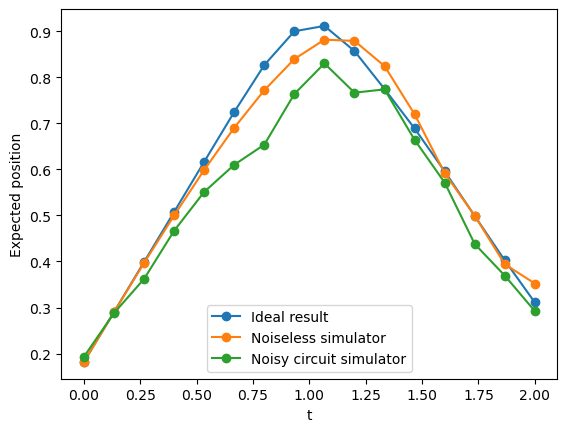

In [17]:
plt.plot(t_vals, ideal_exp_val, '-o', label="Ideal result")
plt.plot(t_vals, sim_exp_val, '-o', label="Noiseless simulator")
plt.plot(t_vals, noisy_sim_exp_val, '-o', label="Noisy circuit simulator")
plt.xlabel("t")
plt.ylabel("Expected position")
plt.legend()
plt.show()

In [18]:
# np.savez(join(SAVE_DIR, "data.npz"), 
#          ideal_dist=ideal_dist,                                         # Ideal QW
#          sim_freq=sim_freq,                                             # Simulator with Hamiltonian embedding
#          ionq_freq_normalized=ionq_freq_normalized,                     # IonQ (normalized)
#          propagation_distance_ideal=propagation_distance_ideal,         # Propagation distance
#          propagation_distance_sim=propagation_distance_sim,
#          propagation_distance_ionq=propagation_distance_ionq,
#          propagation_distance_ionq_err=propagation_distance_ionq_err,   # Propagation distance std error
#          ionq_freq=ionq_freq,                                           # IonQ frequency (unnormalized)
#          num_samples_subspace_ionq=num_samples_subspace_ionq)           # Samples in encoding subspace

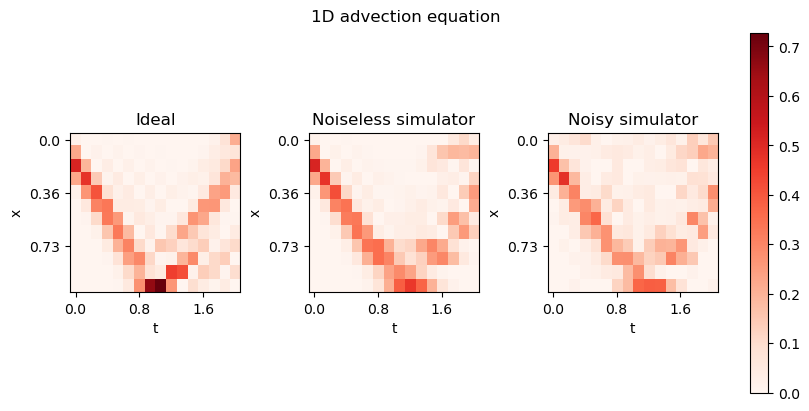

In [19]:
labels = ["Ideal", "Noiseless simulator", "Noisy simulator"]#, "IonQ"]

fig, axs = plt.subplots(1, len(labels), constrained_layout=True, facecolor="white", figsize=(8,4))

max_prob = max(np.max(ideal_dist), np.max(sim_freq_normalized), np.max(noisy_sim_freq_normalized))#, np.max(ionq_freq_normalized))
im = axs[0].matshow(ideal_dist.T, vmin=0, vmax=max_prob, cmap='Reds')
axs[1].matshow(sim_freq_normalized.T, vmin=0, vmax=max_prob, cmap='Reds')
axs[2].matshow(noisy_sim_freq_normalized.T, vmin=0, vmax=max_prob, cmap='Reds')
# axs[2].matshow(ionq_freq_normalized.T, vmin=0, vmax=max_prob)

aspect = 1.25
for i in range(len(labels)):
    axs[i].set_aspect(aspect)
    
    axs[i].set_ylabel("x")
    axs[i].set_yticks(np.arange(ideal_dist.shape[1])[::4])
    axs[i].set_yticklabels([str(round(float(label), 2)) for label in x[::4]])
    axs[i].set_title(labels[i])

    axs[i].set_xlabel("t")
    axs[i].xaxis.set_ticks_position("bottom")
    axs[i].set_xticks(np.arange(ideal_dist.shape[0])[::6])
    axs[i].set_xticklabels([str(round(float(label), 3)) for label in t_vals[::6]])

fig.colorbar(im, ax=axs.ravel().tolist())
fig.suptitle("1D advection equation")
plt.show()

# 2D advection equation

In [45]:
DATA_DIR = "experiment_data"
TASK_DIR = "advection-2d"

CURR_DIR = DATA_DIR
check_and_make_dir(CURR_DIR)
CURR_DIR = join(CURR_DIR, TASK_DIR)
check_and_make_dir(CURR_DIR)

print(CURR_DIR)

use_real_machine = True
if use_real_machine:
    device = "qpu.aria-1"
    # device = "simulator"
    print("Device:", device)
else:
    device = "simulator"

    print("Device:", device)

experiment_data/advection-2d
Device: qpu.aria-1


In [46]:
N = 12
dimension = 2
encoding = "one-hot"
n = num_qubits_per_dim(N, encoding)
codewords = get_codewords(n, dimension, encoding)
bitstrings = get_bitstrings(N, dimension, encoding)

T = 0.3
r = 1                               # Trotter steps
R = 1
c = 1
num_time_points = 31

x_vals = np.linspace(0, R, N)
t_vals = np.linspace(0, T, num_time_points)

num_shots = 200

experiment_info = {
    "N": N,
    "dimension": dimension,
    "encoding": encoding,
    "T": T,
    "R": R,
    "c": c,
    "num_time_points": num_time_points,
    "r": r,
    "num_shots": num_shots
}

hash_str = hashlib.md5(json.dumps(experiment_info).encode("utf-8")).hexdigest()
SAVE_DIR = join(CURR_DIR, hash_str)
check_and_make_dir(SAVE_DIR)

print("Save dir:", SAVE_DIR)

with open(join(SAVE_DIR, "experiment_info.json"), "w") as f:
    json.dump(experiment_info, f)
    f.close()

print("Rough estimate of two qubit gate count (not including state prep):", 1.5 * (dimension * N-1) * 2 * r)

qpu_job_ids_filename = 'job_ids_qpu.json'
sim_job_ids_filename = 'job_ids_sim.json'
noisy_sim_job_ids_filename = 'job_ids_noisy_sim.json'

Save dir: experiment_data/advection-2d/1160cb538d2b40841375a607b22e9218
Rough estimate of two qubit gate count (not including state prep): 69.0


In [47]:
def get_H_d_dim(n : int, d : int, dx):
    H_1D = np.zeros((n,n), dtype=np.complex128)

    for i in range(n):
        H_1D[i, (i+1) % n] = -1j
        H_1D[(i+1) % n, i] = 1j
    H_1D *= (c / (2 * dx))
    dims = [n ** i for i in range(d)]
    return np.sum([tensor([np.identity(dims[d-i-1]), H_1D, np.identity(dims[i])]) for i in range(d)])

State preparation

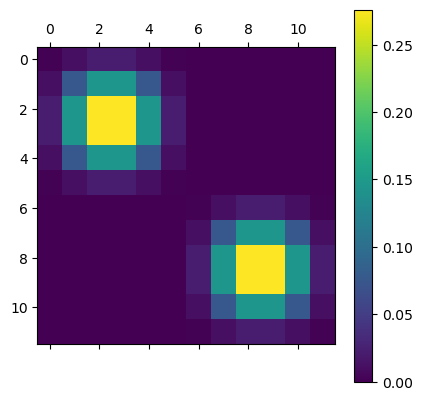

In [48]:
psi_0_2d = np.zeros((N,N))
# theta = 0.5#np.pi/4
# assert theta <= np.pi/4
width = N // 4
sigma = 0.08
gaussian = np.exp(-0.5 * ((np.arange(-width, width) / (N-1)) / sigma) ** 2)
gaussian /= np.linalg.norm(gaussian)


for mean in [N // 4 - 1, 3 * N // 4 - 1]:
    psi_0_2d[mean,mean] = 1
    psi_0_2d[mean+1,mean] = 1
    psi_0_2d[mean,mean+1] = 1
    psi_0_2d[mean+1,mean+1] = 1
    

for mean in [N // 4 - 1, 3 * N // 4 - 1]:

    for i in range(min(width, mean, N - mean - 2)):
        theta = np.arccos(gaussian[width+i] / np.linalg.norm(gaussian[width+i:]))

        a = np.copy(psi_0_2d[:,mean+i+1])
        psi_0_2d[:,mean+i+1] = np.cos(theta) * a
        psi_0_2d[:,mean+i+2] = np.sin(theta) * a

        a = np.copy(psi_0_2d[:,mean-i])
        psi_0_2d[:,mean-i] = np.cos(theta) * a
        psi_0_2d[:,mean-i-1] = np.sin(theta) * a

    for i in range(min(width, mean, N - mean - 2)):
        theta = np.arccos(gaussian[width+i] / np.linalg.norm(gaussian[width+i:]))
        
        a = np.copy(psi_0_2d[mean+i+1,:])
        psi_0_2d[mean+i+1,:] = np.cos(theta) * a
        psi_0_2d[mean+i+2,:] = np.sin(theta) * a

        a = np.copy(psi_0_2d[mean-i,:])
        psi_0_2d[mean-i,:] = np.cos(theta) * a
        psi_0_2d[mean-i-1,:] = np.sin(theta) * a

psi_0_2d /= np.linalg.norm(psi_0_2d)

plt.matshow(psi_0_2d)
plt.colorbar()
plt.show()

Ground truth

In [49]:
# psi_0 = np.zeros(N ** dimension, dtype=np.complex64)
# psi_0_1d = np.zeros(N, dtype=np.complex128)
# # Initialize to Gaussian
# for i in range(N):
#     psi_0_1d[i] = np.exp(-0.5 * ((i / (N-1) - mu) / sigma) ** 2)
    # psi_0_1d[i] = np.sin(2 * np.pi * i / (N-1)) ** 2
psi_0 = psi_0_2d#np.outer(psi_0_1d, psi_0_1d)

# psi_0 = np.zeros((N, N), dtype=np.complex128)
# psi_0[N // 4, N // 4] = 1
# psi_0[3 * N // 4 , 3 * N // 4] = 1
psi_0 = psi_0.flatten()
psi_0 /= np.linalg.norm(psi_0)


dx = R / (N - 1)

H = get_H_d_dim(N, dimension, dx)
# H[0,-1] = 1j
# H[-1,0] = -1j

psi = expm_multiply(-1j * H, psi_0, start=0, stop=T, num=num_time_points)

ideal_dist = np.abs(psi) ** 2

In [50]:
ideal_dist_reshaped = np.reshape(ideal_dist, (num_time_points, N, N))

In [51]:
# for i in range(num_time_points):
#     plt.matshow(ideal_dist_reshaped[i], cmap="Reds")#, interpolation="bicubic")
#     # plt.grid()
#     # plt.xticks(ticks=np.arange(0, N)[::5]-1/2, labels=[str(round(float(label), 2)) for label in x_vals[np.arange(0, N)[::5]]])
#     # plt.yticks(ticks=np.arange(0, N)[::5]-1/2, labels=[str(round(float(label), 2)) for label in x_vals[np.arange(0, N)[::5]]])
#     plt.show()

......

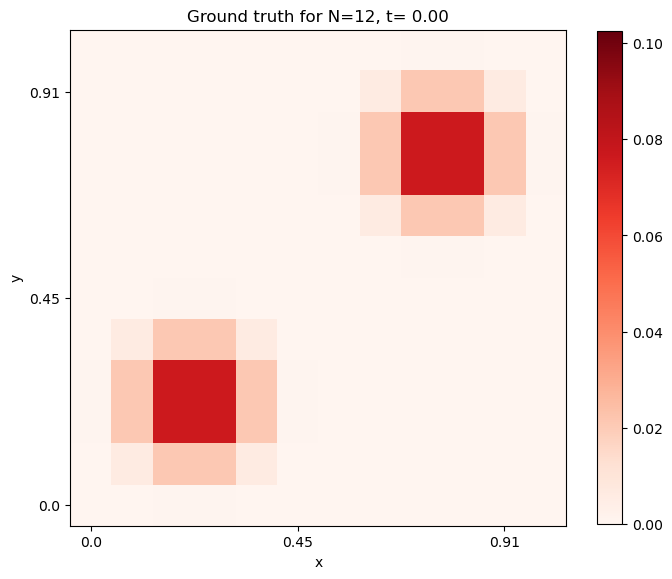

In [53]:
fps = 8
# First set up the figure, the axis, and the plot element we want to animate
fig = plt.figure(figsize=(8,8))
max_val = np.max(ideal_dist_reshaped)
norm = mpl.colors.Normalize(vmin=0, vmax=max_val)
im = plt.imshow(ideal_dist_reshaped[0], cmap="Reds")
plt.title(f"Ground truth, t={t_vals[0] : 0.2f}")
cb = plt.colorbar(im, shrink=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.xticks(np.arange(N)[::5], [str(round(float(label), 2)) for label in x_vals[::5]])
plt.yticks(np.arange(N)[::5], [str(round(float(label), 2)) for label in x_vals[::5]])
plt.gca().invert_yaxis()

def animate(i):
    if i % fps == 0:
        print( '.', end ='' )

    im.set_data(ideal_dist_reshaped[i])
    norm = mpl.colors.Normalize(vmin=0, vmax=max_val)
    im.set_norm(norm)
    plt.title(f"Ground truth for N={N}, t={t_vals[i] : 0.2f}")
    return [im]

anim = animation.FuncAnimation(fig, 
                               animate, 
                               frames=num_time_points,
                               interval = 1000 # in ms
                               )

filename="advection_2d_gt.gif"
writergif = animation.PillowWriter(fps=fps)
anim.save(filename, writer=writergif)

Gate count estimate

In [54]:
instructions = state_prep_2d_advection(N)
instructions += get_adv_circuit(N, T, c, R, r, encoding=encoding, dimension=dimension)
native_instructions, _ = get_native_circuit(dimension * N, instructions)
one_qubit_gate_count, two_qubit_gate_count = get_native_gate_counts(native_instructions)
print(f"1q gates: {one_qubit_gate_count}, 2q gates: {two_qubit_gate_count}")


1q gates: 60, 2q gates: 115


Run tasks

In [55]:
if use_real_machine:
    run_advection_2d(N, T, c, R, r, num_time_points, num_shots, device, SAVE_DIR, use_real_machine, qpu_job_ids_filename)
else:
    run_advection_2d(N, T, c, R, r, num_time_points, num_shots, device, SAVE_DIR, use_real_machine, sim_job_ids_filename, use_noisy_sim=False)
    run_advection_2d(N, T, c, R, r, num_time_points, num_shots, device, SAVE_DIR, use_real_machine, noisy_sim_job_ids_filename, use_noisy_sim=True)

Unitless time:  0.000
1q gates: 12, 2q gates: 43
Saving in experiment_data/advection-2d/1160cb538d2b40841375a607b22e9218
Job id: 75d2234e-7982-4bed-9795-4456824dc779
Unitless time:  0.010
1q gates: 12, 2q gates: 115
Saving in experiment_data/advection-2d/1160cb538d2b40841375a607b22e9218
Job id: 998d8c2a-d9ea-4a80-874c-e75dba799a1e
Unitless time:  0.020
1q gates: 12, 2q gates: 115
Saving in experiment_data/advection-2d/1160cb538d2b40841375a607b22e9218
Job id: 90e13d5b-3d9a-4a6c-bda8-33aa2fe65321
Unitless time:  0.030
1q gates: 12, 2q gates: 115
Saving in experiment_data/advection-2d/1160cb538d2b40841375a607b22e9218
Job id: 78d4b7a3-e773-4a9c-a951-386835016de0
Unitless time:  0.040
1q gates: 12, 2q gates: 115
Saving in experiment_data/advection-2d/1160cb538d2b40841375a607b22e9218
Job id: 061c792d-b2f9-40b2-aaff-f0e7180307c9
Unitless time:  0.050
1q gates: 12, 2q gates: 115
Saving in experiment_data/advection-2d/1160cb538d2b40841375a607b22e9218
Job id: 6aa605a1-8c44-4df9-b877-d09f46d75e5f

Get results

In [40]:
sim_freq = get_results(join(SAVE_DIR, sim_job_ids_filename), num_time_points, codewords)
noisy_sim_freq = get_results(join(SAVE_DIR, noisy_sim_job_ids_filename), num_time_points, codewords)

Getting job: c56fb0de-e4d6-47c3-854c-f4a683d95b48
Job status: completed
Getting job: ebe8a01b-cbd6-401b-88bc-d9548a13f062
Job status: completed
Getting job: 43252cd8-94c6-4af9-8891-4ad3fd147fc2
Job status: completed
Getting job: 5c136f24-947d-4997-b340-057aea00bdaf
Job status: completed
Getting job: 8fe4ccca-5b2d-4e8a-a2fe-95afa0968ec6
Job status: completed
Getting job: 1d28c323-806c-4e08-8aee-9c55e2850fa9
Job status: completed
Getting job: e4aecefc-1902-4b6a-8d2c-0fae06ae5bc3
Job status: completed
Getting job: 6192a1e9-5958-4d81-99a4-24eba70a4137
Job status: completed
Getting job: 8b88f7ae-32d1-4f5f-b17c-7186c9d2faed
Job status: completed
Getting job: 749bdd29-9c23-4d22-9053-34c2e008fa53
Job status: completed
Getting job: 92c83145-bfc9-400e-80fd-41859ea689ca
Job status: completed
Getting job: b7a613c0-4110-416c-a96f-e919b2f85906
Job status: completed
Getting job: c131733b-4a6e-4d20-ab68-55b3f3d7391d
Job status: completed
Getting job: 17c3b16c-6420-4a8d-806a-b0f630b160ea
Job status: co

In [56]:
ionq_freq = get_results(join(SAVE_DIR, qpu_job_ids_filename), num_time_points, codewords)

Getting job: 75d2234e-7982-4bed-9795-4456824dc779
Job status: ready


FileNotFoundError: Job not completed

Post-processing

In [41]:
sim_freq_normalized = np.zeros_like(sim_freq)
for i in range(num_time_points):
    if np.sum(sim_freq[i]) > 0:
        sim_freq_normalized[i] = sim_freq[i] / np.sum(sim_freq[i])
sim_dist_reshaped = np.reshape(sim_freq_normalized, (num_time_points, N, N))

noisy_sim_freq_normalized = np.zeros_like(noisy_sim_freq)
for i in range(num_time_points):
    if np.sum(noisy_sim_freq[i]) > 0:
        noisy_sim_freq_normalized[i] = noisy_sim_freq[i] / np.sum(noisy_sim_freq[i])
noisy_sim_dist_reshaped = np.reshape(noisy_sim_freq_normalized, (num_time_points, N, N))

# ionq_freq_normalized = np.zeros_like(ionq_freq)
# for i in range(num_time_points):
#     if np.sum(ionq_freq[i]) > 0:
#         ionq_freq_normalized[i] = ionq_freq[i] / np.sum(ionq_freq[i])

# num_samples_subspace_ionq = np.sum(ionq_freq, axis=1) * num_shots

......

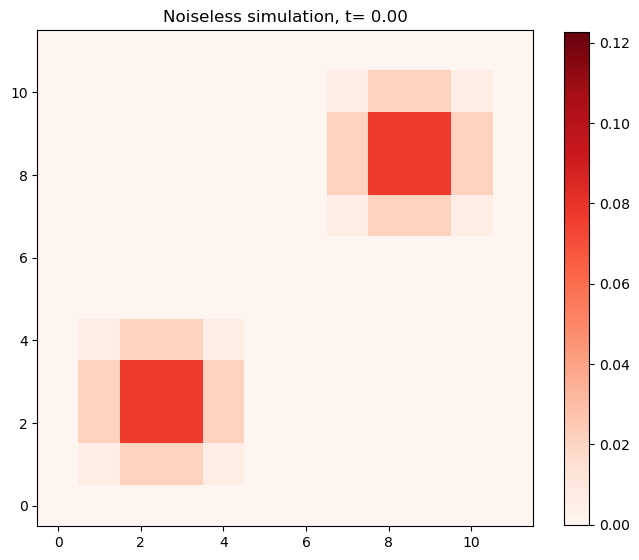

In [42]:
fps = 8
# First set up the figure, the axis, and the plot element we want to animate
fig = plt.figure(figsize=(8,8))
max_val = np.max(sim_dist_reshaped)
norm = mpl.colors.Normalize(vmin=0, vmax=max_val)
im = plt.imshow(sim_dist_reshaped[0], cmap="Reds")
plt.title(f"Noiseless simulation, t={t_vals[0] : 0.2f}")
cb = plt.colorbar(im, shrink=0.8)
plt.gca().invert_yaxis()

def animate(i):
    if i % fps == 0:
        print( '.', end ='' )

    im.set_data(sim_dist_reshaped[i])
    norm = mpl.colors.Normalize(vmin=0, vmax=max_val)
    im.set_norm(norm)
    plt.title(f"Noiseless simulation, t={t_vals[i] : 0.2f}")
    return [im]

anim = animation.FuncAnimation(fig, 
                               animate, 
                               frames=num_time_points,
                               interval = 1000 # in ms
                               )

filename="advection_2d_sim.gif"
writergif = animation.PillowWriter(fps=fps)
anim.save(filename, writer=writergif)

..........

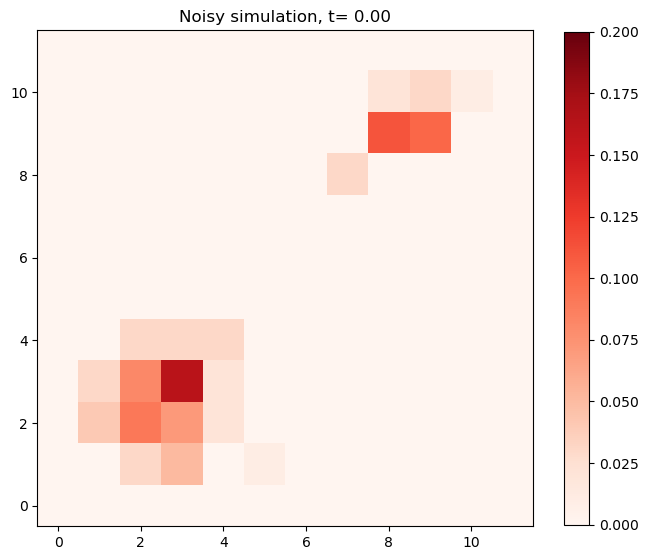

In [43]:
fps = 4
# First set up the figure, the axis, and the plot element we want to animate
fig = plt.figure(figsize=(8,8))
max_val = np.max(noisy_sim_dist_reshaped)
norm = mpl.colors.Normalize(vmin=0, vmax=max_val)
im = plt.imshow(noisy_sim_dist_reshaped[0], cmap="Reds")
plt.title(f"Noisy simulation, t={t_vals[0] : 0.2f}")
cb = plt.colorbar(im, shrink=0.8)
plt.gca().invert_yaxis()

def animate(i):
    if i % fps == 0:
        print( '.', end ='' )

    im.set_data(noisy_sim_dist_reshaped[i])
    norm = mpl.colors.Normalize(vmin=0, vmax=max_val)
    im.set_norm(norm)
    plt.title(f"Noisy simulation, t={t_vals[i] : 0.2f}")
    return [im]

anim = animation.FuncAnimation(fig, 
                               animate, 
                               frames=num_time_points,
                               interval = 1000 # in ms
                               )

filename="advection_2d_noisy_sim.gif"
writergif = animation.PillowWriter(fps=fps)
anim.save(filename, writer=writergif)

..........

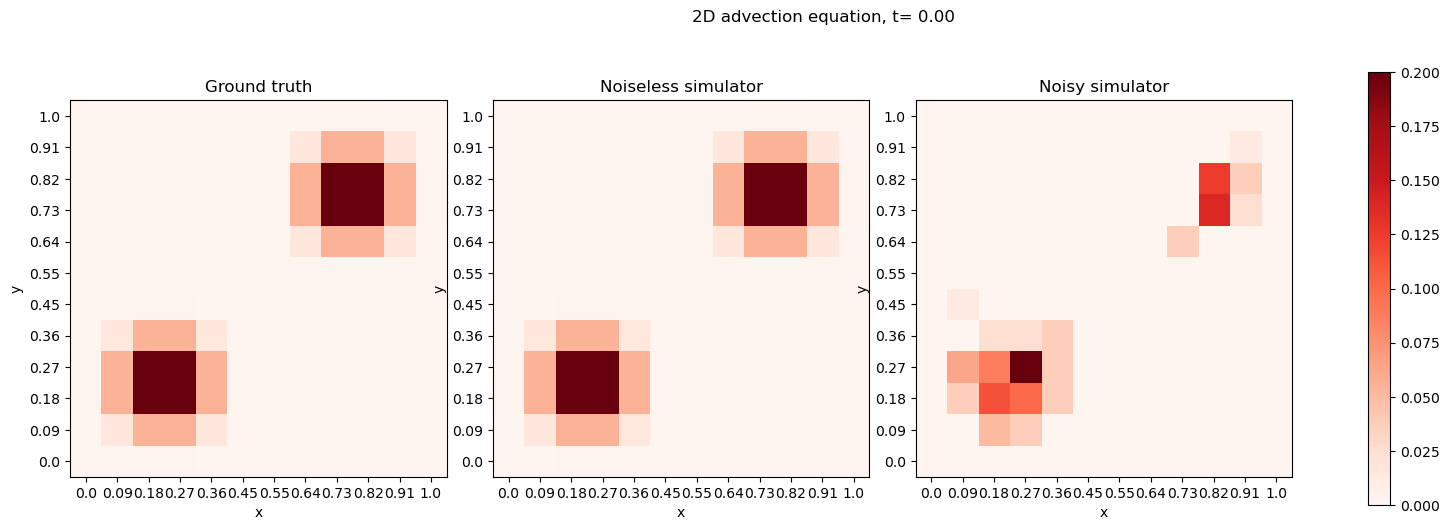

In [44]:
labels = ["Ground truth", "Noiseless simulator", "Noisy simulator"]

fps = 4
aspect = 1

fig, axs = plt.subplots(1, len(labels), figsize=(16,6))
plt.tight_layout()
max_prob = max(np.max(ideal_dist_reshaped), np.max(sim_dist_reshaped), np.max(noisy_sim_dist_reshaped))

im = axs[0].imshow(ideal_dist_reshaped[0].T, cmap="Reds")
axs[1].imshow(sim_dist_reshaped[0].T, cmap="Reds")
axs[2].imshow(noisy_sim_dist_reshaped[0].T, cmap="Reds")

for j in range(len(labels)):
    axs[j].set_aspect(aspect)
    axs[j].set_title(labels[j])

    axs[j].set_ylabel("y")
    axs[j].set_yticks(np.arange(N)[::1])
    axs[j].set_yticklabels([str(round(float(label), 2)) for label in x_vals[::1]])
    axs[j].set_ylim(axs[j].get_ylim()[::-1])

    axs[j].set_xlabel("x")
    axs[j].xaxis.set_ticks_position("bottom")
    axs[j].set_xticks(np.arange(N)[::1])
    axs[j].set_xticklabels([str(round(float(label), 2)) for label in x_vals[::1]])

norm = mpl.colors.Normalize(vmin=0, vmax=max_prob)
# cb = plt.colorbar(im, shrink=0.8)
fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.8)

def animate(i):
    if i % fps == 0:
        print( '.', end ='' )

    axs[0].imshow(ideal_dist_reshaped[i].T, cmap="Reds")
    axs[1].imshow(sim_dist_reshaped[i].T, cmap="Reds")
    axs[2].imshow(noisy_sim_dist_reshaped[i].T, cmap="Reds")
    
    norm = mpl.colors.Normalize(vmin=0, vmax=max_prob)
    im.set_norm(norm)
    # plt.title(f"Noisy simulation, t={t_vals[i] : 0.2f}")

    # fig.colorbar(im, ax=axs.ravel().tolist())
    fig.suptitle(f"2D advection equation, t={t_vals[i] : 0.2f}")
    # plt.show()
    return [im]

anim = animation.FuncAnimation(fig, 
                               animate, 
                               frames=num_time_points,
                               interval = 1000 # in ms
                               )

filename="advection_2d_full.gif"
writergif = animation.PillowWriter(fps=fps)
anim.save(filename, writer=writergif)